
# 5 minute quickstart tutorial

Follow this example to get started with DeepInverse in under 5 minutes.

**Contents**

1. [Install](#install)_
2. [Physics](#physics)_
3. [Models](#models)_
4. [Datasets](#datasets)_
5. [What's next](#what-s-next)_


## 1. Install

First, install and import the latest stable release of `deepinv`:

In [1]:
# 🚀 To get started, install DeepInverse by running this cell
%%capture
# Install deepinv
!pip install deepinv

We then get the device (CPU in the case of this example).

In [ ]:
import deepinv as dinv
import torch

device = dinv.utils.get_freer_gpu() if torch.cuda.is_available() else "cpu"

## 2. Physics




In DeepInverse, `x` are images:




In [ ]:
x = dinv.utils.load_example("butterfly.png", device=device)

Images are tensors of shape `B, C, ...` where `B` is batch size, `C` are channels and `...` are spatial dimensions:



In [ ]:
print(x.shape)

torch.Size([1, 3, 256, 256])


`Imaging forward operators <physics_intro>` are called `physics` and simulate
measurements `y` from `x`.




In [ ]:
physics = dinv.physics.Inpainting(x.shape[1:], mask=0.3, device=device)

y = physics(x)

DeepInverse implements
`many different types of physics <physics>` across various imaging modalities.
Physics also possess noise models such as Gaussian or Poisson noise.

.. hint::
    Do you get a matplotlib LaTeX error when plotting? Disable LaTeX using `dinv.utils.disable_tex()`



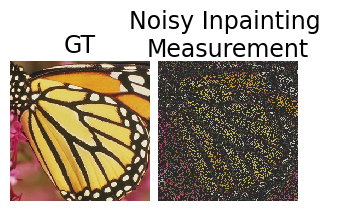

In [ ]:
physics.noise_model = dinv.physics.GaussianNoise(sigma=0.1)

y = physics(x)

dinv.utils.plot({"GT": x, "Noisy Inpainting \nMeasurement": y})

Many physics also take
`physics parameters <parameter-dependent-operators>` such as `mask`, `filter`, `sigma` etc.:



In [ ]:
# Blur with Gaussian filter parameter
filter = dinv.physics.blur.gaussian_blur((5, 5))

physics = dinv.physics.BlurFFT(x.shape[1:], filter=filter, device=device)

# Simulate measurements
y = physics(x)

You can easily use your own params by passing these into the `physics`,
or you can use a `generator` to `generate random params <physics_generators>`:



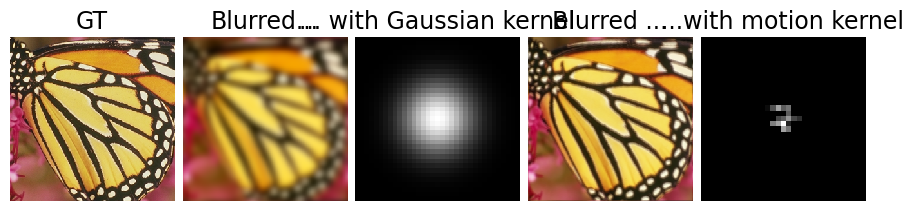

In [ ]:
# Blur kernel random generator
physics_generator = dinv.physics.generator.MotionBlurGenerator(
    psf_size=(31, 31), num_channels=3, device=device
)

# Generate a dict of random params {"filter": ...}
params = physics_generator.step()

# Update physics during forward call
y2 = physics(x, **params)

dinv.utils.plot(
    {
        "GT": x,
        "Blurred...": y,
        "... with Gaussian kernel": filter,
        "Blurred ...": y2,
        "...with motion kernel": params["filter"],
    }
)

Physics are powerful objects and `have many methods <physics_intro>`, for example a
pseudo-inverse:




In [ ]:
# You can also update params like so
physics.update(filter=filter.to(device))

x_pinv = physics.A_dagger(y)

As it is well-known in the field of inverse problems, the pseudo-inverse can give good results
if the problem is noiseless, but it completely fails in the presence of noise - this is why we need reconstructors!



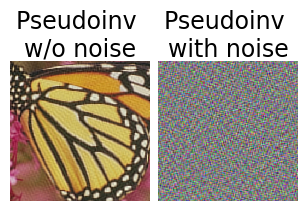

In [ ]:
physics.noise_model = dinv.physics.GaussianNoise(sigma=0.1)

y = physics(x)

x_pinv_noise = physics.A_dagger(y)

dinv.utils.plot(
    {"Pseudoinv \nw/o noise": x_pinv, "Pseudoinv \nwith noise": x_pinv_noise}
)

.. tip::

   Want to use DeepInverse with your own physics operator? Check out `sphx_glr_auto_examples_basics_demo_custom_physics.py` for a tutorial!




## 3. Models

In DeepInverse, a `model` is a reconstruction algorithm that
**reconstructs** images from `y` and knowledge of `physics`.

.. tip::
    Many models, such as :class:`Reconstruct Anything Model <deepinv.models.RAM>`, are `pretrained reconstructors <pretrained-models>` and can
    be used out of the box. See `sphx_glr_auto_examples_basics_demo_pretrained_model.py` for a full example.




In [ ]:
model = dinv.models.RAM(pretrained=True, device=device)

x_hat = model(y, physics)

Downloading: "https://huggingface.co/mterris/ram/resolve/main/ram.pth.tar" to /root/.cache/torch/hub/checkpoints/ram.pth.tar


100%|██████████| 136M/136M [00:00<00:00, 282MB/s]


Plot the image `x`, the measurement `y` and the reconstructed image
`x_hat` and compute `metrics <metric>`:




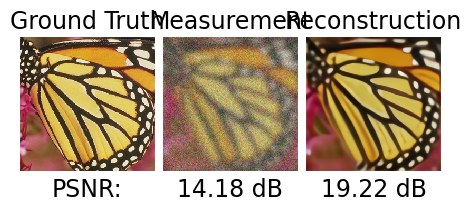

In [ ]:
metric = dinv.metric.PSNR()

psnr_y = metric(y, x).item()
psnr_x_hat = metric(x_hat, x).item()

dinv.utils.plot(
    {
        "Ground Truth": x,
        "Measurement": y,
        "Reconstruction": x_hat,
    },
    subtitles=["PSNR:", f"{psnr_y:.2f} dB", f"{psnr_x_hat:.2f} dB"],
)

Some models are only `denoisers <denoisers>` that **denoise**
images from `y` and `sigma`, which can be used to build many
`model-based reconstruction algorithms <iterative>`.




Downloading: "https://huggingface.co/deepinv/drunet/resolve/main/drunet_deepinv_color_finetune_22k.pth?download=true" to /root/.cache/torch/hub/checkpoints/drunet_deepinv_color_finetune_22k.pth


100%|██████████| 125M/125M [00:00<00:00, 288MB/s]


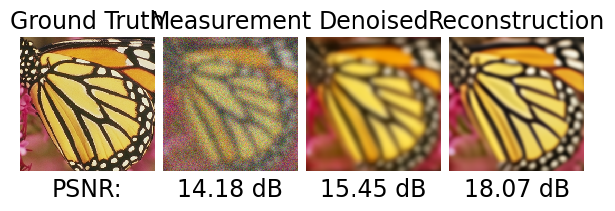

In [ ]:
denoiser = dinv.models.DRUNet(device=device)

x_denoised = denoiser(y, sigma=0.1)

model = dinv.optim.DPIR(sigma=0.1, denoiser=denoiser, device=device)

x_hat = model(y, physics)

dinv.utils.plot(
    {
        "Ground Truth": x,
        "Measurement": y,
        "Denoised": x_denoised,
        "Reconstruction": x_hat,
    },
    subtitles=[
        "PSNR:",
        f"{dinv.metric.PSNR()(y, x).item():.2f} dB",
        f"{dinv.metric.PSNR()(x_denoised, x).item():.2f} dB",
        f"{dinv.metric.PSNR()(x_hat, x).item():.2f} dB",
    ],
)

DeepInverse covers
`many frameworks of reconstruction algorithms <reconstructors>`
including `deep model architectures <deep-reconstructors>`, `iterative algorithms <iterative>`, `sampling algorithms <sampling>`
(e.g. diffusion models), and `unfolded models <unfolded>`.




In [ ]:
# Reconstruct Anything Model foundation model
model = dinv.models.RAM(pretrained=True, device=device)

.. tip::

   Want to use DeepInverse with your own network? Just inherit from the reconstructor base class :class:`deepinv.models.Reconstructor`!




## 4. Datasets

You can use DeepInverse with `dataset <datasets>`, for testing or training. First,
define a ground-truth dataset. We implement wrappers for
`many popular imaging datasets <datasets>` across domains including natural images,
medical imaging, satellite imaging, etc.

.. tip::
    It's easy to use your own dataset with DeepInverse. See `sphx_glr_auto_examples_basics_demo_custom_dataset.py` for a tutorial.




In [ ]:
dataset = dinv.datasets.SimpleFastMRISliceDataset(
    "data", anatomy="brain", download=True
)

  0%|          | 0/820534 [00:00<?, ?it/s]

`Datasets <datasets>` return either `x`, tuples `x, y` or `x, y, params` of images,
measurements, and optional physics parameters. Given a ground-truth
dataset, you can simulate a dataset with random physics:




In [ ]:
physics = dinv.physics.MRI(device=device)

physics_generator = dinv.physics.generator.RandomMaskGenerator(
    (320, 320), device=device
)

path = dinv.datasets.generate_dataset(
    dataset,
    physics,
    save_dir="data",
    physics_generator=physics_generator,
    device=device,
)

dataset = dinv.datasets.HDF5Dataset(path, load_physics_generator_params=True)

Dataset has been saved at data/dinv_dataset0.h5


You can use this dataset to `test or train <trainer>` a model:




/usr/local/lib/python3.12/dist-packages/deepinv/training/trainer.py:542: UserWarning: Update progress bar frequency of 1 may slow down training on GPU. Consider setting freq_update_progress_bar > 1.
  warnings.warn(
Test:  50%|█████     | 1/2 [00:24<00:12, 12.43s/it, PSNR=39.6, PSNR no learning=30.3]

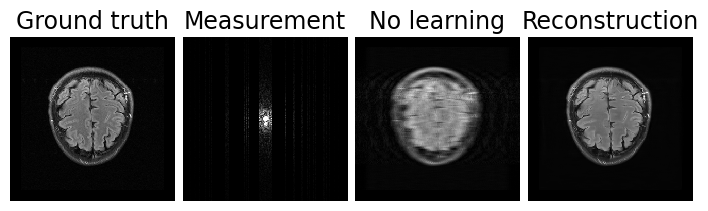

Test: 100%|██████████| 2/2 [00:25<00:00, 12.64s/it, PSNR=39.6, PSNR no learning=30.3]

Test results:
PSNR no learning: 30.306 +- 1.113
PSNR: 39.620 +- 1.637


{'PSNR no learning': 30.30557346343994,
 'PSNR no learning_std': 1.1131017997011592,
 'PSNR': 39.62000274658203,
 'PSNR_std': 1.6372954421052268}

In [ ]:
import torch

dinv.test(
    model,
    torch.utils.data.DataLoader(dataset),
    physics,
    plot_images=True,
    device=device,
)

.. tip::

   Want to use DeepInverse with your own dataset? Check out `sphx_glr_auto_examples_basics_demo_custom_dataset.py` for a tutorial!




🎉 Well done, you now know how to use DeepInverse!

## What's next?

-  Try more basic examples, including
   `how to inference a pretrained model <sphx_glr_auto_examples_basics_demo_pretrained_model.py>`,
   `how to use your own dataset <sphx_glr_auto_examples_basics_demo_custom_dataset.py>`, or
   `how to use your custom physics operator <sphx_glr_auto_examples_basics_demo_custom_physics.py>`.
-  Checkout a YouTube tutorial on our [YouTube Channel](https://www.youtube.com/@deepinv).
-  Dive deeper into our full library of examples.
-  Read the `User Guide <user_guide>` for further details on the
   concepts introduced here.
-  Want help?
   [Open an issue](https://github.com/deepinv/deepinv/issues) ask
   a message on our [Discord](https://discord.gg/qBqY5jKw3p) or
   get in touch with our
   [MAINTAINERS](https://github.com/deepinv/deepinv/blob/main/MAINTAINERS.md).


